In [2]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap
import matplotlib.pyplot as plt

In [3]:
seed = 2724

### Import data

In [4]:
DF_PATH = "mod04_data/sample.csv"
df = pd.read_csv(DF_PATH)

### Separate data by independent (X) and dependent (y) variables

In [5]:
X = df[["income", "education_years", "zipcode_score"]]
y = df["target"]

### Split the data into a _training_ set (to build a model) and _test_ set (to validate a model)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

### Build a model on the training set

In [7]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=seed
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=2724)

### Use SHAP to explain the model on test data

In [8]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

 99%|===================| 1489/1500 [00:39<00:00]        

This will allow us to see which variables are most important to predicting the outcome.

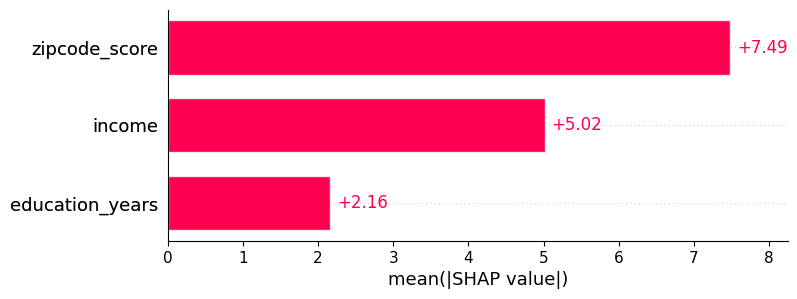

In [9]:
shap.plots.bar(shap_values)

### Import the `group` variable, which was **not** used in training this model.

In [10]:
X_test_with_group = X_test.copy()
X_test_with_group["group"] = df.loc[X_test.index, "group"]

### Look at the difference in SHAP values between the two groups across the variables used in the model.

In [11]:
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df["group"] = X_test_with_group["group"].values

shap_df.groupby("group").mean()

,income,education_years,zipcode_score
group,,,
0,1.086254,-0.170779,5.866534
1,1.020094,-0.192841,-6.859435


### Let's put `group` and `zipcode_score` in the same plot

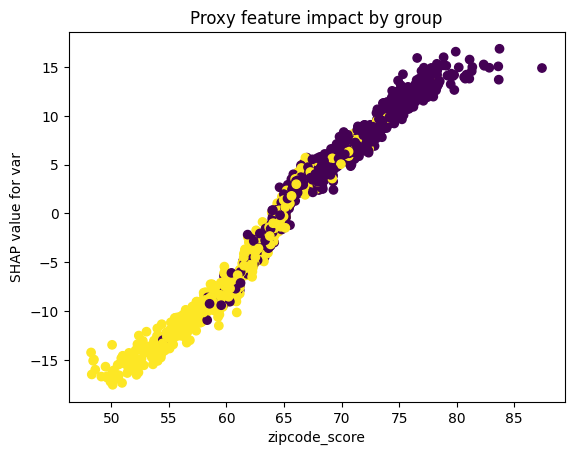

In [12]:
def plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("zipcode_score")

# Discussion Questions

### What is a _SHAP_ (or Shapley) value? 

The SHAP(Shapley) value comes from a game-theory technique and it measures how much each input feature(in this case zipcode_score, income, and education years) contributes to the final prediction, and the sum of all the SHAP values will be the difference between the model's prediction and the average prediction.
source: https://www.youtube.com/watch?v=b9qqbFudVhI 

### Suppose you built this model and then it is peer reviewed by another entity. If the reviewer asks whether you used the variable `group` in your model, what would your answer be?

If the reviewer asked whether we used the variable group in our model the answer would be no because we did not train the model on the variable group(as indicated by Import the group variable, which was not used in training this model instruction/header cell) however we do use the variable group as the data to test the performance our model on.

### If the reviewer asks whether the outcome of your model is correlated with `group`, what would your answer be?

If the reviewer asked whether the outcome of our model is correlated with group our answer would be no because while the SHAP values between the model and the model's predictions on group are similar for income(1.086254 vs. 1.020094) and education years(-0.170779 vs. -0.192841) they are drastically different for zipcode_score(5.866534 vs. -6.859435) and zipcode_score is the most important variable in predicting the outcome as shown by the bar plot, thus since the most important variable has extreamly opposing SHAP values we would notsay the model is correlated with group.

### Construct a "proxy feature impact by group" plot for `income`. How is this plot different from the one for `zipcode_score`?

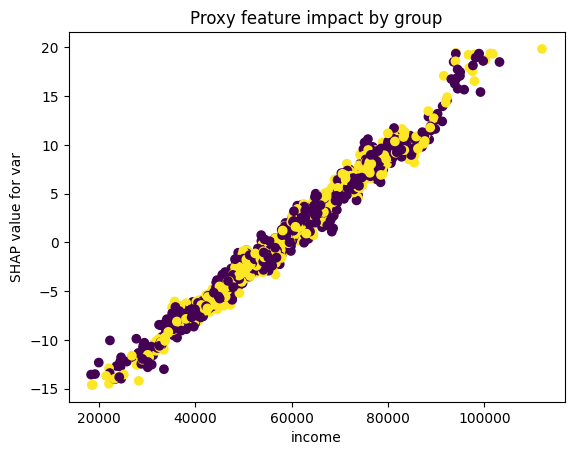

In [13]:
def my_plot_shap(var):
    # Extract SHAP values for the feature
    shap_var = shap_values[:, var].values

    # Plot the values of each group using different colors
    plt.figure()
    plt.scatter(
        X_test[var],
        shap_var,
        c=X_test_with_group["group"]
    )
    plt.xlabel(var)
    plt.ylabel(f"SHAP value for var")
    plt.title("Proxy feature impact by group")
    plt.show()

plot_shap("income")

The "proxy feature impact by group" plot for income is quite different from the plot for zipcode_score as seen by the values on the x-intercept(20000 starting and 20k steps for income plot vs. 50 starting and 5 steps for zipcode_score plot), slight shape variation(the zipcode_score plot had a bit of an s shaped curve whereas the income plot was primarily linear), and most noteably the distance between the different groups points/the yellow and purple points on the plots(the income plot had very little distance between the points and the yellow and purple were jumbled together at all point in the plot where as for the zipcode_score plot the yellow points were mostly grouped together on the lower left, with some mix in the center, and then purple grouped together on the top right, which tells us that both groups had similar SHAP values for income and then for zipcode_score we see the yellow group typically had lower SHAP values for zipcode_score and the purple group usually had higher SHAP values for zipcode_score).

### If, instead, you were the **reviewer**, what other questions might you ask the person who built this model? Give at least two.

If I were the reviewer some other questions I might ask the person who built this model are: (1)Are there any other important variables that would be important to predicting an accurate income? and (2)What are some ways you could improve your model to be better correlated with group?